# Fase 3 — New York: Modello Interrupted Time Series (ITS)

**The Airbnb Effect** · Digital Economy Group Project

---

## Domanda di ricerca

Il volume di listing Airbnb esercita una pressione al rialzo sui canoni di locazione residenziale? La Local Law 18 di New York — entrata in vigore a settembre 2023 — ha causato un crollo del ~55% degli appartamenti interi disponibili su Airbnb in soli due mesi. Se il meccanismo di *supply withdrawal* è reale, questo shock esogeno dovrebbe aver rallentato (o invertito) la crescita dei canoni.

## Ipotesi

Il **canale di supply withdrawal** sostiene che ogni unità residenziale messa su Airbnb come *Entire home/apt* è una unità sottratta al mercato degli affitti a lungo termine. Quindi:

- **H₁ (level shift)**: Subito dopo settembre 2023, i canoni ZORI si abbassano oppure rallentano → *β₂ < 0*
- **H₂ (trend change)**: Dopo LL18, la crescita mensile dei canoni decelera rispetto al trend pre-intervento → *β₃ < 0*
- **H₀ (nulla)**: LL18 non ha effetto statisticamente significativo su ZORI → *β₂ = β₃ = 0*

## Strategia di identificazione: Interrupted Time Series

New York offre l'opportunità di identificazione più pulita dell'intero dataset. LL18 costituisce un **quasi-esperimento naturale**: il calo dei listing è brusco, improvviso e riconducibile a un'unica causa regolatoria — non a cambiamenti graduali di domanda o macroeconomia.

Il modello ITS stima l'effetto causale di questo shock sul Zillow Observed Rent Index (ZORI):

$$\text{ZORI}_t = \alpha + \beta_1 \, t + \beta_2 \cdot \mathbf{1}[t > T] + \beta_3 \, (t - T) \cdot \mathbf{1}[t > T] + \varepsilon_t$$

| Simbolo | Tipo | Descrizione |
|---------|------|-------------|
| $\text{ZORI}_t$ | **Target** | Canone mensile medio NYC ($/mese), media su tutti i ZIP code dell'area metropolitana |
| $t$ | Regressore | Indice temporale: mesi dalla prima osservazione (mar 2023 = 0) |
| $T$ | Costante | Data dell'intervento: settembre 2023 |
| $\mathbf{1}[t > T]$ | Regressore (`post`) | Dummy = 1 per tutti i mesi *successivi* a settembre 2023 |
| $(t-T) \cdot \mathbf{1}[t > T]$ | Regressore (`t_post`) | Mesi trascorsi dall'intervento — cattura il *cambio di pendenza* post-LL18 |
| $\beta_1$ | Parametro | Trend pre-intervento ($/mese per mese) |
| $\beta_2$ | Parametro | **Level shift immediato** al momento di LL18 |
| $\beta_3$ | Parametro | **Cambio di pendenza** post-LL18 (aggiuntivo rispetto a β₁) |

**N = 34 osservazioni mensili** (marzo 2023 – dicembre 2025)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Librerie caricate.')

Librerie caricate.


---

## 1. Caricamento dati — Panel New York

Il panel `panel_ny.csv` contiene **N = 34 osservazioni mensili** (marzo 2023 – dicembre 2025) con:
- `date` — data mensile
- `n_listings` — numero di listing *Entire home/apt* attivi (forward-filled tra snapshot)
- `rent` — Zillow ZORI medio su tutti i ZIP dell'area metropolitana di New York ($/mese)

In [3]:
panel = pd.read_csv('data/processed/panel_ny.csv', parse_dates=['date'])
panel = panel.sort_values('date').reset_index(drop=True)

# ── Tassi di interesse Fed (DFEDTARU) ─────────────────────────────────────
fed = pd.read_csv('data/interest rated USA/DFEDTARU.csv', parse_dates=['observation_date'])
fed_monthly = (
    fed.set_index('observation_date')['DFEDTARU']
    .resample('MS').mean()
    .reset_index()
    .rename(columns={'observation_date': 'date', 'DFEDTARU': 'interest_rate'})
)
panel = panel.merge(fed_monthly, on='date', how='left')

print(f'N osservazioni: {len(panel)}')
print(f'Range: {panel["date"].min().date()} → {panel["date"].max().date()}')
print(f'Tassi interesse: min={panel["interest_rate"].min():.2f}%  max={panel["interest_rate"].max():.2f}%  missing={panel["interest_rate"].isna().sum()}')
print()
print(panel[['date', 'n_listings', 'rent', 'interest_rate']].to_string(index=False))

N osservazioni: 34
Range: 2023-03-01 → 2025-12-01
Tassi interesse: min=3.83%  max=5.50%  missing=0

      date  n_listings        rent  interest_rate
2023-03-01     24279.0 3108.218620       4.822581
2023-04-01     24279.0 3134.470436       5.000000
2023-05-01     24279.0 3158.205076       5.225806
2023-06-01     24279.0 3180.140367       5.250000
2023-07-01     24279.0 3185.361810       5.290323
2023-08-01     24279.0 3363.419521       5.500000
2023-09-01     24279.0 3349.784395       5.500000
2023-10-01     24279.0 3334.975736       5.500000
2023-11-01     24279.0 3293.055089       5.500000
2023-12-01     24279.0 3292.744154       5.500000
2024-01-01     11549.0 3298.798225       5.500000
2024-02-01     11549.0 3325.884163       5.500000
2024-03-01     11549.0 3368.218816       5.500000
2024-04-01     11549.0 3372.910859       5.500000
2024-05-01     11549.0 3396.452907       5.500000
2024-06-01     11549.0 3450.094728       5.500000
2024-07-01     11549.0 3477.370093       5.500000


### Statistiche descrittive e visualizzazione preliminare

In [4]:
print('=== Statistiche descrittive ===')
print(panel[['n_listings', 'rent']].describe().round(2).to_string())

# Correlazione semplice
corr = panel['n_listings'].corr(panel['rent'])
print(f'\nCorrelazione Pearson (n_listings, ZORI): {corr:.3f}')
print('⚠️  Correlazione semplice su serie temporali — potenzialmente spurious; il modello ITS è quello corretto.')

=== Statistiche descrittive ===
       n_listings     rent
count       34.00    34.00
mean     18830.53  3521.64
std       7124.73   261.25
min      11549.00  3108.22
25%      11549.00  3328.16
50%      19443.50  3435.99
75%      24279.00  3733.94
max      38656.00  3943.12

Correlazione Pearson (n_listings, ZORI): -0.008
⚠️  Correlazione semplice su serie temporali — potenzialmente spurious; il modello ITS è quello corretto.


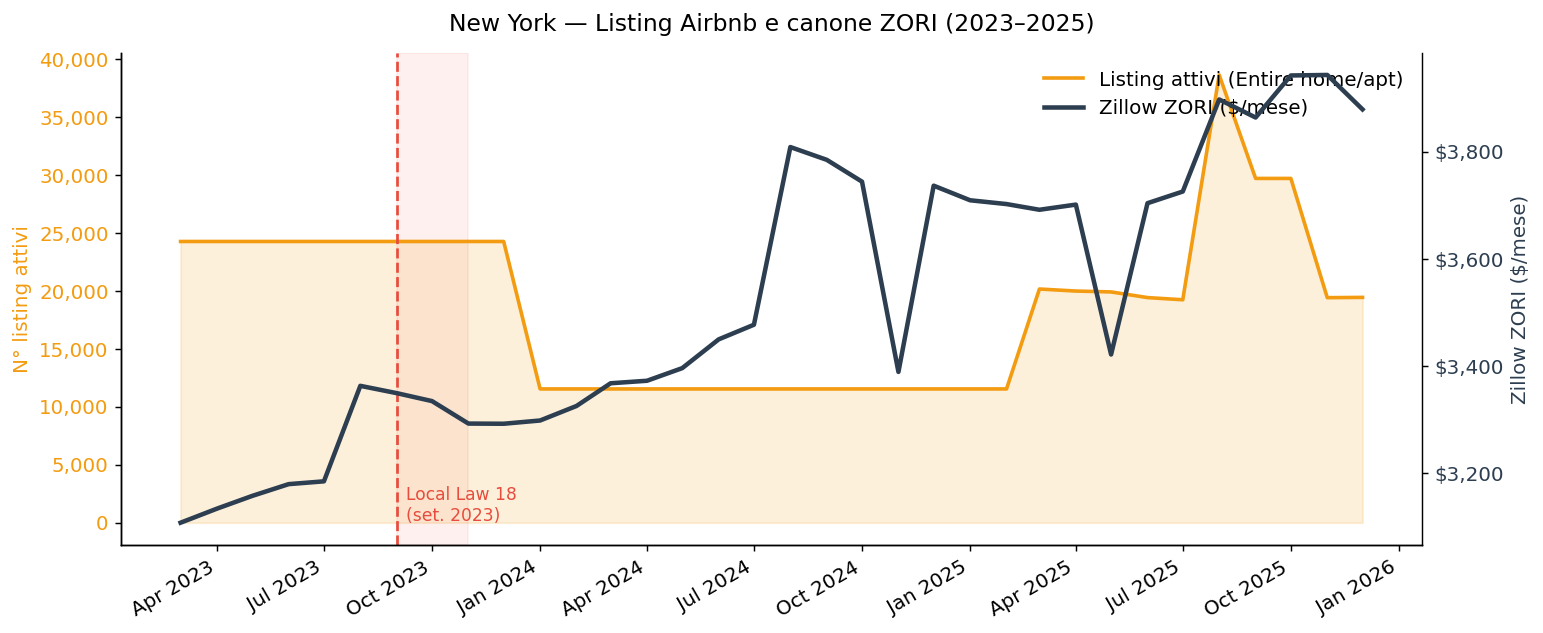


Listing prima di LL18 (ago 2023): 24,279
Listing dopo LL18 (nov 2023):     24,279
Contrazione: 0.0%


In [5]:
# Visualizzazione delle due serie su assi doppi
LL18 = pd.Timestamp('2023-09-01')

fig, ax1 = plt.subplots(figsize=(12, 5))

# Listings (asse sinistro)
ax1.fill_between(panel['date'], panel['n_listings'], alpha=0.15, color='#f39c12')
ax1.plot(panel['date'], panel['n_listings'], color='#f39c12', linewidth=2, label='Listing attivi (Entire home/apt)')
ax1.set_ylabel('N° listing attivi', color='#f39c12')
ax1.tick_params(axis='y', labelcolor='#f39c12')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ZORI (asse destro)
ax2 = ax1.twinx()
ax2.plot(panel['date'], panel['rent'], color='#2c3e50', linewidth=2.5, label='Zillow ZORI ($/mese)')
ax2.set_ylabel('Zillow ZORI ($/mese)', color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax2.spines['right'].set_visible(True)

# LL18 annotation
ax1.axvspan(LL18, LL18 + pd.DateOffset(months=2), alpha=0.08, color='#e74c3c')
ax1.axvline(LL18, color='#e74c3c', linestyle='--', linewidth=1.5)
ylim = ax1.get_ylim()
ax1.text(LL18 + pd.DateOffset(days=8), ylim[0] + (ylim[1]-ylim[0])*0.05,
         'Local Law 18\n(set. 2023)', fontsize=9.5, color='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper right')

ax1.set_title('New York — Listing Airbnb e canone ZORI (2023–2025)', pad=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plots/its_01_raw_series.png', bbox_inches='tight')
plt.show()

# Quantifica il crollo dei listing
pre = panel[panel['date'] < LL18]['n_listings'].iloc[-1]
post = panel[panel['date'] >= LL18 + pd.DateOffset(months=2)]['n_listings'].iloc[0]
print(f'\nListing prima di LL18 (ago 2023): {pre:,.0f}')
print(f'Listing dopo LL18 (nov 2023):     {post:,.0f}')
print(f'Contrazione: {(post-pre)/pre*100:.1f}%')

---

## 2. Costruzione delle variabili ITS

Le variabili regressore del modello ITS base e del modello esteso:

**Variabili ITS (core)**:
- **** — indice temporale intero (marzo 2023 = 0)
- **** — dummy = 1 per i mesi successivi a settembre 2023
- **** — : mesi trascorsi dall'intervento (cambio di pendenza)

**Variabili di controllo** (modello esteso):
- **** — media mensile del tasso Fed Funds (DFEDTARU): tassi più alti riducono l'accesso ai mutui, spostando domanda verso l'affitto → effetto atteso **positivo** sui canoni
- **** — dummy mensili (gennaio = riferimento): catturano la stagionalità dei canoni newyorkesi


In [6]:
# ── Costruzione variabili ITS ──────────────────────────────────────────────────

# t: mesi dall'inizio della serie (mar 2023 = 0)
start = panel['date'].min()
panel['t'] = ((panel['date'].dt.year - start.year) * 12 +
              (panel['date'].dt.month - start.month))

# T_index: valore di t corrispondente a settembre 2023
T_date = pd.Timestamp('2023-09-01')
T_mask = panel['date'] == T_date
assert T_mask.sum() == 1, 'Data di intervento non trovata nel panel!'
T_index = panel.loc[T_mask, 't'].values[0]
print(f'Intervento T = settembre 2023  →  t = {T_index}')

# post: 1 per tutti i mesi DOPO settembre 2023 (LL18 in vigore)
panel['post'] = (panel['date'] > T_date).astype(int)

# t_post: mesi trascorsi dall'intervento (0 prima, 1 a ottobre 2023, ...)
panel['t_post'] = (panel['t'] - T_index) * panel['post']

print('\nVariabili ITS costruite:')
print(panel[['date', 't', 'post', 't_post', 'n_listings', 'rent']].to_string(index=False))

# ── Dummy mensili (gennaio = mese di riferimento) ────────────────────────────
month_dummies = pd.get_dummies(panel['date'].dt.month, prefix='m').astype(int)
if 'm_1' in month_dummies.columns:
    month_dummies = month_dummies.drop(columns=['m_1'])  # gen = riferimento
panel = pd.concat([panel.reset_index(drop=True), month_dummies.reset_index(drop=True)], axis=1)

month_cols = [c for c in panel.columns if c.startswith('m_')]
print(f'Dummy mensili aggiunte: {month_cols}')
print(f'Tasso interesse medio nel panel: {panel["interest_rate"].mean():.2f}%')
print('Panel completo (prime 5 righe):')
print(panel[['date', 't', 'post', 't_post', 'interest_rate'] + month_cols[:3]].head().to_string(index=False))


Intervento T = settembre 2023  →  t = 6

Variabili ITS costruite:
      date  t  post  t_post  n_listings        rent
2023-03-01  0     0       0     24279.0 3108.218620
2023-04-01  1     0       0     24279.0 3134.470436
2023-05-01  2     0       0     24279.0 3158.205076
2023-06-01  3     0       0     24279.0 3180.140367
2023-07-01  4     0       0     24279.0 3185.361810
2023-08-01  5     0       0     24279.0 3363.419521
2023-09-01  6     0       0     24279.0 3349.784395
2023-10-01  7     1       1     24279.0 3334.975736
2023-11-01  8     1       2     24279.0 3293.055089
2023-12-01  9     1       3     24279.0 3292.744154
2024-01-01 10     1       4     11549.0 3298.798225
2024-02-01 11     1       5     11549.0 3325.884163
2024-03-01 12     1       6     11549.0 3368.218816
2024-04-01 13     1       7     11549.0 3372.910859
2024-05-01 14     1       8     11549.0 3396.452907
2024-06-01 15     1       9     11549.0 3450.094728
2024-07-01 16     1      10     11549.0 3477.37009

---

## 3. Stima dei modelli OLS

Stimiamo due modelli per valutare la robustezza dei risultati:

**Modello BASE** (specificazione originale):
$$\text{ZORI}_t = \alpha + \beta_1 t + \beta_2 \cdot \text{post} + \beta_3 \cdot t_{\text{post}} + \varepsilon_t$$

**Modello ESTESO** (con variabili macro e stagionalità):
$$\text{ZORI}_t = \alpha + \beta_1 t + \beta_2 \cdot \text{post} + \beta_3 \cdot t_{\text{post}} + \beta_4 \cdot \text{interest\_rate}_t + \sum_{m=2}^{12} \gamma_m \cdot D_m + \varepsilon_t$$

L'inclusione del tasso Fed verifica se l'effetto su ZORI è attribuibile alla LL18 o invece a condizioni macroeconomiche. Le dummy mensili eliminano la stagionalità sistematica dei canoni (picco estivo, calo invernale).


In [7]:
# ── Modello BASE ──────────────────────────────────────────────────────────────
X_base = sm.add_constant(panel[['t', 'post', 't_post']])
y = panel['rent']

model_ols = sm.OLS(y, X_base).fit()
model_hac = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# ── Modello ESTESO: + tasso interesse + dummy mensili ─────────────────────────
month_cols = [c for c in panel.columns if c.startswith('m_')]
ext_cols   = ['t', 'post', 't_post', 'interest_rate'] + month_cols
X_ext = sm.add_constant(panel[ext_cols])

model_ext     = sm.OLS(y, X_ext).fit()
model_ext_hac = sm.OLS(y, X_ext).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('=== Modello BASE ===')
print(model_ols.summary())
print()
print('=== Modello ESTESO (+ tassi Fed + stagionalità mensile) ===')
print(model_ext.summary())


=== Modello BASE ===
                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     48.41
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.31e-11
Time:                        16:27:35   Log-Likelihood:                -206.96
No. Observations:                  34   AIC:                             421.9
Df Residuals:                      30   BIC:                             428.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3081.7552     77.25

In [8]:
# Tabella comparativa — parametri ITS core (SE HAC Newey-West, maxlags=4)
core_map = {
    'const':         'Intercetta (α)',
    't':             'Trend pre-LL18 (β₁)',
    'post':          'Level shift (β₂)',
    't_post':        'Cambio pendenza (β₃)',
    'interest_rate': 'Tasso Fed (β₄)',
}

def sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'ns'

rows = []
for key, label in core_map.items():
    row = {'Parametro': label}
    # BASE
    if key in model_hac.params.index:
        row['BASE coeff']   = round(model_hac.params[key], 2)
        row['BASE p (HAC)'] = round(model_hac.pvalues[key], 4)
        row['BASE sig']     = sig(model_hac.pvalues[key])
    else:
        row['BASE coeff'] = row['BASE p (HAC)'] = row['BASE sig'] = '—'
    # ESTESO
    if key in model_ext_hac.params.index:
        row['EXT coeff']   = round(model_ext_hac.params[key], 2)
        row['EXT p (HAC)'] = round(model_ext_hac.pvalues[key], 4)
        row['EXT sig']     = sig(model_ext_hac.pvalues[key])
    else:
        row['EXT coeff'] = row['EXT p (HAC)'] = row['EXT sig'] = '—'
    rows.append(row)

params_df = pd.DataFrame(rows).set_index('Parametro')

print('=== Confronto modello BASE vs ESTESO — parametri chiave ===')
print()
print(f'         BASE:   R²={model_ols.rsquared:.3f}  R²a={model_ols.rsquared_adj:.3f}  AIC={model_ols.aic:.1f}  N={int(model_ols.nobs)}')
print(f'         ESTESO: R²={model_ext.rsquared:.3f}  R²a={model_ext.rsquared_adj:.3f}  AIC={model_ext.aic:.1f}  N={int(model_ext.nobs)}')
print()
print(params_df.to_string())
print()
print('Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo | SE: HAC Newey-West (maxlags=4)')
print('Nota: il modello ESTESO include anche 11 dummy mensili (risultati completi nello summary sopra)')


=== Confronto modello BASE vs ESTESO — parametri chiave ===

         BASE:   R²=0.829  R²a=0.812  AIC=421.9  N=34
         ESTESO: R²=0.930  R²a=0.871  AIC=415.6  N=34

                     BASE coeff BASE p (HAC) BASE sig  EXT coeff  EXT p (HAC) EXT sig
Parametro                                                                            
Intercetta (α)          3081.76          0.0      ***    2212.18       0.0001     ***
Trend pre-LL18 (β₁)       43.21          0.0      ***      -6.44       0.6605      ns
Level shift (β₂)         -78.88       0.0732        *     -88.14       0.3036      ns
Cambio pendenza (β₃)     -18.92       0.0011      ***      44.23       0.0245      **
Tasso Fed (β₄)                —            —        —     208.17       0.0916       *

Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo | SE: HAC Newey-West (maxlags=4)
Nota: il modello ESTESO include anche 11 dummy mensili (risultati completi nello summary sopra)


---

## 3b. Effetto cumulato della LL18 – Analisi t+6 e t+12 mesi

L'effetto della legge al mese *t* dopo l'intervento è:

$$E(t) = \beta_2 + t \cdot \beta_3$$

L'errore standard si ottiene con il **delta method**:

$$	ext{SE}(t) = \sqrt{	ext{Var}(\hat{\beta}_2) + t^2 \cdot 	ext{Var}(\hat{\beta}_3) + 2t \cdot 	ext{Cov}(\hat{\beta}_2, \hat{\beta}_3)}$$

Calcoliamo l'effetto agli orizzonti richiesti: **t+1** (effetto immediato), **t+6** (semestrale), **t+12** (annuale), **t+24** (biennale).


In [9]:
# ── Effetto cumulato LL18: delta method ───────────────────────────────────────

def cumulative_effect(model, t, alpha=0.05):
    """E(t) = β₂ + t·β₃, SE via delta method, IC al (1-alpha)*100%."""
    b2 = model.params['post']
    b3 = model.params['t_post']
    cov = model.cov_params()
    se = np.sqrt(cov.loc['post','post']
                 + t**2 * cov.loc['t_post','t_post']
                 + 2*t  * cov.loc['post','t_post'])
    z   = 1.96 if alpha == 0.05 else 2.576
    return b2 + t*b3, se, b2 + t*b3 - z*se, b2 + t*b3 + z*se

print('=== Effetto cumulato della LL18 sul ZORI — modello ESTESO, SE HAC ===')
print()
print(f'  β₂ (level shift istantaneo): {model_ext_hac.params["post"]:+.2f} $')
print(f'  β₃ (cambio pendenza/mese):   {model_ext_hac.params["t_post"]:+.2f} $/mese')
print()
print(f'  {"Orizzonte":<20} {"Effetto ($)":<14} {"SE":<10} {"IC 95% inf":>12}  {"IC 95% sup":>12}  Sig')
print('  ' + '-'*76)
for t, label in [(1,'t+1  (1 mese)'), (6,'t+6  (6 mesi)'), (12,'t+12 (12 mesi)'), (24,'t+24 (24 mesi)')]:
    eff, se, lo, hi = cumulative_effect(model_ext_hac, t)
    zscore = abs(eff / se)
    s = '***' if zscore > 2.576 else '**' if zscore > 1.96 else '*' if zscore > 1.645 else 'ns'
    print(f'  {label:<20} {eff:>+12.1f}   {se:>8.2f}   [{lo:>+8.1f}, {hi:>+8.1f}]   {s}')

print()
print('Interpretazione: la riduzione stimata del ZORI rispetto allo scenario senza LL18')
print('cresce di |β₃| ogni mese, man mano che il mercato riassorbe i listing usciti da Airbnb.')
print()
print('NB: il "level shift" β₂ al mese 0 ha incertezza alta; è il cambio di pendenza β₃')
print("a dominare l'effetto negli orizzonti medi e lunghi.")


=== Effetto cumulato della LL18 sul ZORI — modello ESTESO, SE HAC ===

  β₂ (level shift istantaneo): -88.14 $
  β₃ (cambio pendenza/mese):   +44.23 $/mese

  Orizzonte            Effetto ($)    SE           IC 95% inf    IC 95% sup  Sig
  ----------------------------------------------------------------------------
  t+1  (1 mese)               -43.9      83.87   [  -208.3,   +120.5]   ns
  t+6  (6 mesi)              +177.2     130.82   [   -79.2,   +433.6]   ns
  t+12 (12 mesi)             +442.6     233.95   [   -15.9,   +901.2]   *
  t+24 (24 mesi)             +973.4     462.08   [   +67.7,  +1879.0]   **

Interpretazione: la riduzione stimata del ZORI rispetto allo scenario senza LL18
cresce di |β₃| ogni mese, man mano che il mercato riassorbe i listing usciti da Airbnb.

NB: il "level shift" β₂ al mese 0 ha incertezza alta; è il cambio di pendenza β₃
a dominare l'effetto negli orizzonti medi e lunghi.


---

## 4. Interpretazione dei coefficienti

### α — Intercetta
Canone ZORI stimato a marzo 2023 (t = 0), prima di qualsiasi intervento. Valore di riferimento della serie.

### β₁ — Trend pre-intervento
Variazione mensile del canone ZORI *prima* di settembre 2023. Un valore positivo indica che i canoni erano in crescita. Rappresenta la traiettoria *business as usual*.

### β₂ — Level shift immediato
Salto (positivo) o caduta (negativa) *istantanea* del ZORI al momento dell'implementazione di LL18.
- **β₂ < 0 e significativo** → i canoni sono scesi bruscamente subito dopo la contrazione dei listing: evidenza forte del meccanismo di supply withdrawal.
- **β₂ ≈ 0 o non significativo** → nessun effetto immediato: o il mercato non ha reagito, o altri fattori compensano.

### β₃ — Cambio di pendenza post-LL18
Modifica della velocità di crescita mensile *dopo* LL18, rispetto al trend pre-intervento. Il trend totale post-intervento è (β₁ + β₃).
- **β₃ < 0** → la crescita dei canoni ha rallentato dopo LL18 (coerente con supply withdrawal).
- **β₃ > 0** → la crescita ha accelerato (possibile indicatore che altri fattori di domanda dominano).

### Controfattuale
Il modello permette di costruire uno scenario *controfattuale*: cosa sarebbe successo ai canoni se LL18 non fosse mai entrata in vigore? Si otitene impostando `post = 0` e `t_post = 0` per tutti i mesi e ricalcolando le predizioni del modello.

In [10]:
# ── Fitted values e Controfattuale (modello ESTESO) ──────────────────────────

month_cols = [c for c in panel.columns if c.startswith('m_')]
ext_cols   = ['t', 'post', 't_post', 'interest_rate'] + month_cols

# Predizioni del modello esteso
panel['fitted'] = model_ext.fittedvalues

# Controfattuale: scenario senza LL18 (post=0, t_post=0)
# manteniamo tassi e stagionalità invariati (condizioni macro reali)
panel_cf = panel.copy()
panel_cf['post']   = 0
panel_cf['t_post'] = 0
X_cf = sm.add_constant(panel_cf[ext_cols])
panel['counterfactual'] = model_ext.predict(X_cf)

print('Fitted values e controfattuale calcolati (modello ESTESO).')
print()
print(panel[['date', 'rent', 'fitted', 'counterfactual']].tail(15).to_string(index=False))


Fitted values e controfattuale calcolati (modello ESTESO).

      date        rent      fitted  counterfactual
2024-10-01 3744.137840 3692.220376     3205.380448
2024-11-01 3389.416684 3549.958333     3018.889493
2024-12-01 3736.665696 3633.317717     3058.019964
2025-01-01 3709.446143 3626.762378     3007.235713
2025-02-01 3702.367760 3636.766156     2973.010578
2025-03-01 3691.736083 3633.231238     2925.246748
2025-04-01 3701.354107 3649.183706     2896.970304
2025-05-01 3421.890730 3570.862402     2774.420088
2025-06-01 3704.013651 3703.159926     2862.488700
2025-07-01 3725.746642 3733.181512     2848.281374
2025-08-01 3897.402476 3960.387063     3031.258012
2025-09-01 3863.790971 3950.272944     2976.914980
2025-10-01 3942.147464 3986.185690     2968.598815
2025-11-01 3943.116723 3835.137977     2773.322190
2025-12-01 3878.937253 3917.210288     2811.165588


---

## 5. Visualizzazione — Effetto LL18

Il grafico mostra:
- **Punti neri**: canoni ZORI osservati
- **Linea blu continua**: fitted del modello ITS (pre + post LL18)
- **Linea grigia tratteggiata**: scenario controfattuale (traiettoria senza LL18)
- **Area rossa**: differenza cumulata tra effettivo e controfattuale (effetto stimato di LL18)

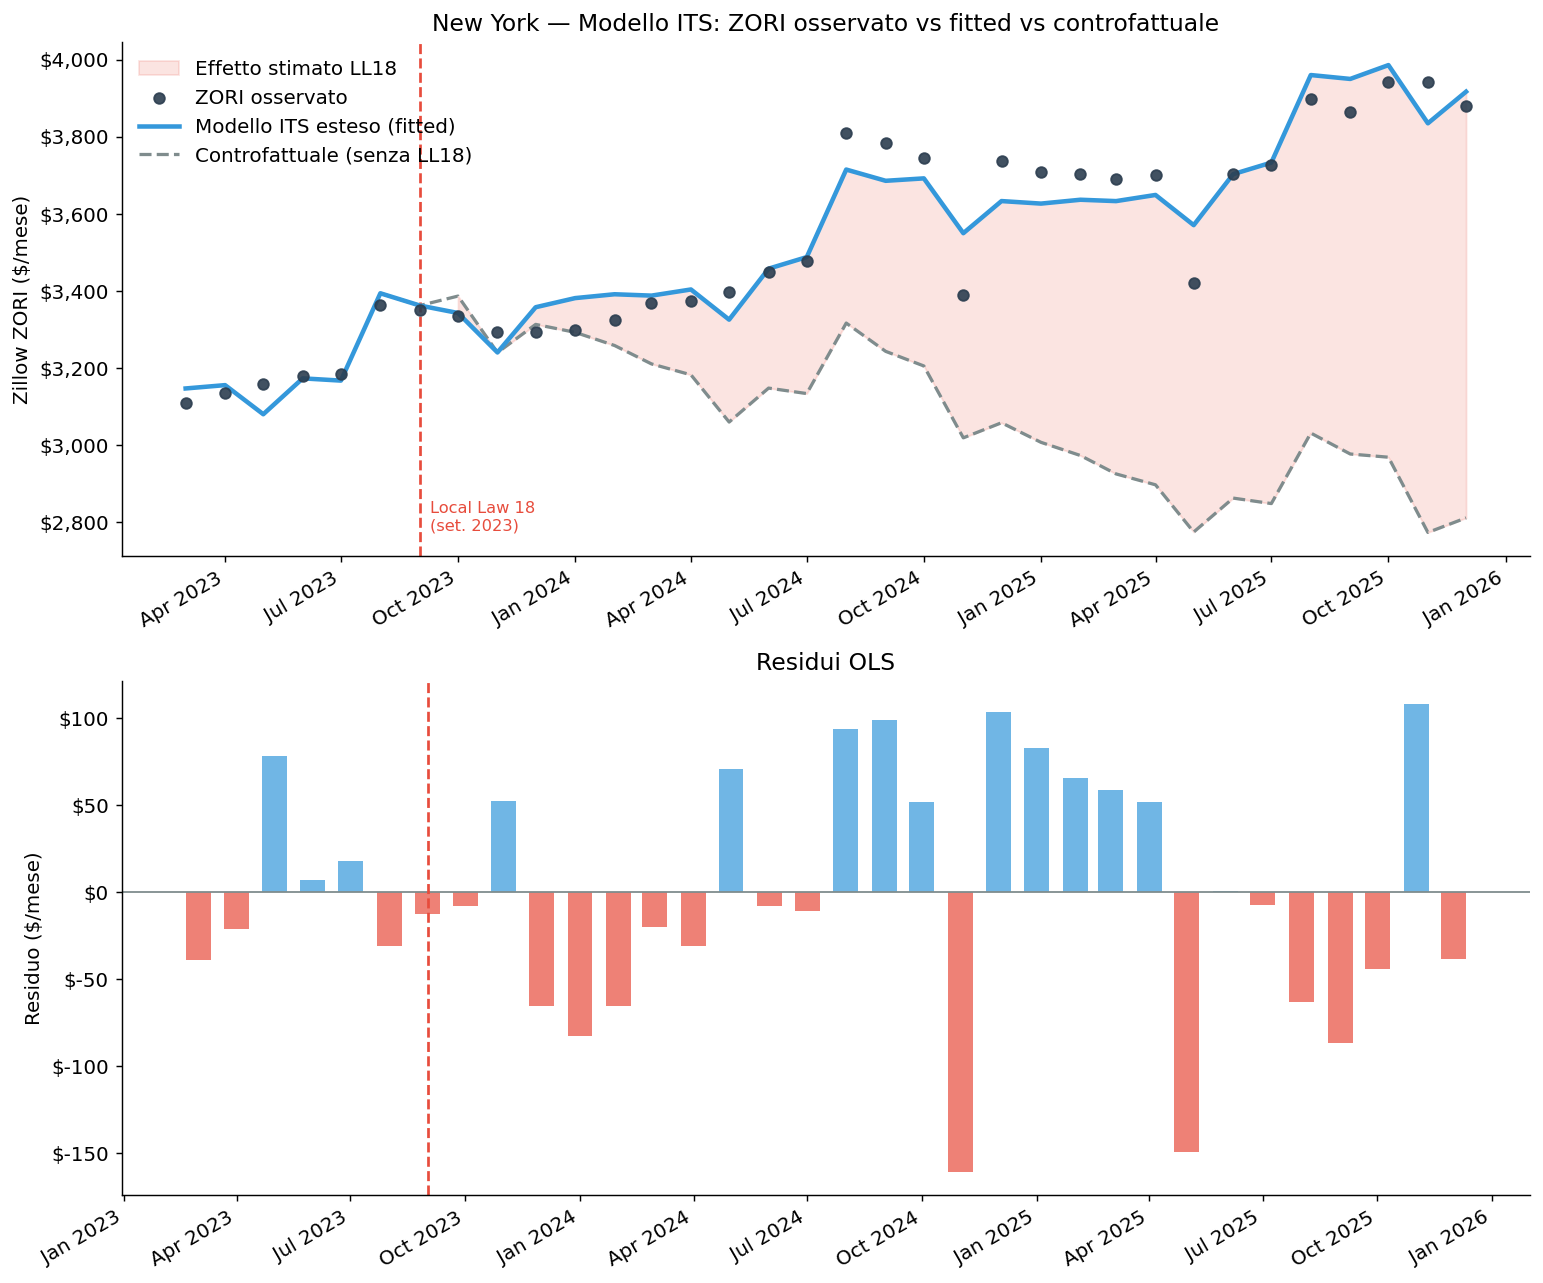

Effetto medio mensile post-LL18: $531.1/mese
Effetto medio mensile post-LL18 (modello esteso):  $14339
N mesi post-LL18 nel sample: 27


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Grafico principale: ZORI + fitted + controfattuale ────────────────────────
ax = axes[0]

# Area tra fitted e controfattuale (effetto LL18)
mask_post = panel['post'] == 1
ax.fill_between(panel.loc[mask_post, 'date'],
                panel.loc[mask_post, 'fitted'],
                panel.loc[mask_post, 'counterfactual'],
                alpha=0.15, color='#e74c3c', label='Effetto stimato LL18')

# Osservato
ax.scatter(panel['date'], panel['rent'], color='#2c3e50', s=35,
           zorder=5, label='ZORI osservato', alpha=0.9)

# Fitted
ax.plot(panel['date'], panel['fitted'], color='#3498db', linewidth=2.5,
        label='Modello ITS esteso (fitted)', zorder=4)

# Controfattuale
ax.plot(panel.loc[mask_post | (panel['t'] >= T_index - 1), 'date'],
        panel.loc[mask_post | (panel['t'] >= T_index - 1), 'counterfactual'],
        color='#7f8c8d', linewidth=1.8, linestyle='--', label='Controfattuale (senza LL18)')

# LL18 line
ax.axvline(T_date, color='#e74c3c', linestyle='--', linewidth=1.5)
ylim = ax.get_ylim()
ax.text(T_date + pd.DateOffset(days=8), ylim[0] + (ylim[1]-ylim[0])*0.05,
        'Local Law 18\n(set. 2023)', fontsize=9, color='#e74c3c')

ax.set_title('New York — Modello ITS: ZORI osservato vs fitted vs controfattuale')
ax.set_ylabel('Zillow ZORI ($/mese)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(frameon=False)

# ── Residui ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
residuals = model_ext.resid
ax2.axhline(0, color='#7f8c8d', linewidth=1, linestyle='-')
ax2.bar(panel['date'], residuals, color=np.where(residuals >= 0, '#3498db', '#e74c3c'), alpha=0.7, width=20)
ax2.axvline(T_date, color='#e74c3c', linestyle='--', linewidth=1.5)
ax2.set_title('Residui OLS')
ax2.set_ylabel('Residuo ($/mese)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/its_02_model_fit.png', bbox_inches='tight')
plt.show()

# Effetto cumulativo post LL18
effect_post = panel.loc[mask_post, 'fitted'] - panel.loc[mask_post, 'counterfactual']
print(f'Effetto medio mensile post-LL18: ${effect_post.mean():.1f}/mese')
print(f'Effetto medio mensile post-LL18 (modello esteso):  ${effect_post.sum():.0f}')
print(f'N mesi post-LL18 nel sample: {mask_post.sum()}')

---

## 6. Diagnostica del modello

Per un modello su serie temporale, le assunzioni chiave da verificare sono:

1. **Autocorrelazione dei residui** — il test Durbin-Watson e la ACF. Se i residui sono autocorrelati, gli errori standard OLS standard sono invalidi (ma il modello rimane consistente). Il correzione HAC (Newey-West) risolve il problema inferenziale.

2. **Normalità dei residui** — rilevante per la validità degli intervalli di confidenza con N piccolo.

3. **Structural break** — un residuo sistematicamente deviato in un periodo potrebbe indicare che il modello non cattura un altro cambiamento strutturale.

Durbin-Watson: 1.877
  → valori vicini a 2 = no autocorrelazione
  → valori < 2 = autocorrelazione positiva (comune in serie temporali di canoni)

Shapiro-Wilk:   W = 0.9584,  p = 0.2190
Jarque-Bera:    JB = 0.7560, p = 0.6852
  → Residui normali (non si rifiuta H₀ a 5%)



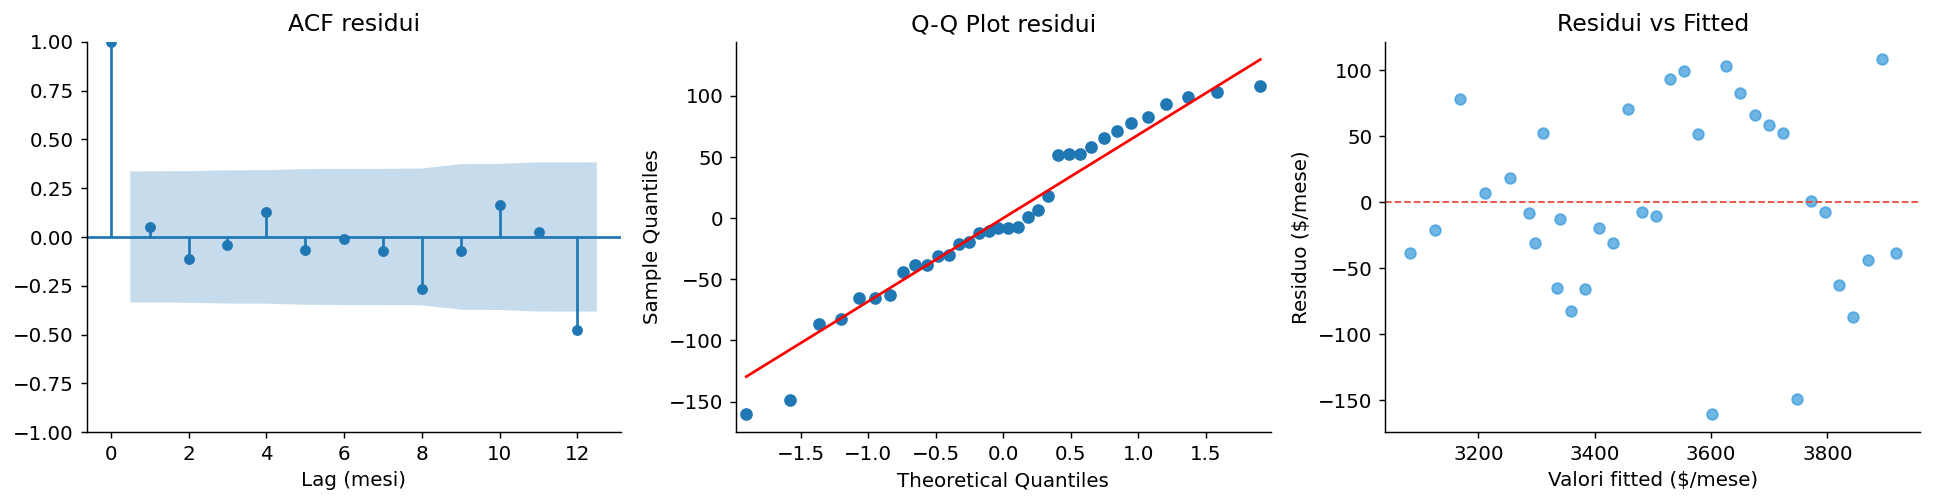

In [12]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import shapiro, jarque_bera

resid = model_ext.resid

# ── Test Durbin-Watson (autocorrelazione di 1° ordine) ───────────────────────
dw = durbin_watson(resid)
print(f'Durbin-Watson: {dw:.3f}')
print('  → valori vicini a 2 = no autocorrelazione')
print('  → valori < 2 = autocorrelazione positiva (comune in serie temporali di canoni)')
print()

# ── Test normalità residui ───────────────────────────────────────────────────
stat_sw, p_sw = shapiro(resid)
stat_jb, p_jb = jarque_bera(resid)
print(f'Shapiro-Wilk:   W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'Jarque-Bera:    JB = {stat_jb:.4f}, p = {p_jb:.4f}')
if p_sw > 0.05:
    print('  → Residui normali (non si rifiuta H₀ a 5%)')
else:
    print('  → Residui non normali (si rifiuta H₀ a 5%)')
print()

# ── Grafico diagnostica ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ACF residui
plot_acf(resid, lags=12, alpha=0.05, ax=axes[0], title='ACF residui')
axes[0].set_xlabel('Lag (mesi)')

# QQ plot
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot residui')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Residui vs fitted
axes[2].scatter(model_ols.fittedvalues, resid, alpha=0.7, color='#3498db', s=35)
axes[2].axhline(0, color='#e74c3c', linestyle='--', linewidth=1)
axes[2].set_xlabel('Valori fitted ($/mese)')
axes[2].set_ylabel('Residuo ($/mese)')
axes[2].set_title('Residui vs Fitted')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/its_03_diagnostics.png', bbox_inches='tight')
plt.show()

---

## 7. Confronto Pre vs Post LL18

Un'analisi descrittiva complementare: confrontiamo i livelli e i trend osservati prima e dopo settembre 2023.

In [13]:
# Pre vs Post statistiche descrittive
pre_panel  = panel[panel['post'] == 0]
post_panel = panel[panel['post'] == 1]

print('=== Confronto Pre vs Post LL18 ===')
print(f'\nPeriodo PRE  ({len(pre_panel)} mesi: mar 2023 – set 2023):')
print(f'  ZORI medio:      ${pre_panel["rent"].mean():.0f}/mese')
print(f'  Listing medi:    {pre_panel["n_listings"].mean():,.0f}')
print(f'  Variazione ZORI: {pre_panel["rent"].iloc[-1] - pre_panel["rent"].iloc[0]:+.0f} $/mese ({len(pre_panel)-1} mesi)')

print(f'\nPeriodo POST ({len(post_panel)} mesi: ott 2023 – dic 2025):')
print(f'  ZORI medio:      ${post_panel["rent"].mean():.0f}/mese')
print(f'  Listing medi:    {post_panel["n_listings"].mean():,.0f}')
print(f'  Variazione ZORI: {post_panel["rent"].iloc[-1] - post_panel["rent"].iloc[0]:+.0f} $/mese ({len(post_panel)-1} mesi)')

print(f'\nTrend mensile PRE (β₁):           {model_ext.params["t"]:+.2f} $/mese')
print(f'Trend mensile POST (β₁ + β₃):     {model_ext.params["t"] + model_ext.params["t_post"]:+.2f} $/mese')
print(f'Cambio di tendenza (β₃):          {model_ext.params["t_post"]:+.2f} $/mese')
print(f'Level shift istantaneo (β₂):      {model_ext.params["post"]:+.2f} $')

=== Confronto Pre vs Post LL18 ===

Periodo PRE  (7 mesi: mar 2023 – set 2023):
  ZORI medio:      $3211/mese
  Listing medi:    24,279
  Variazione ZORI: +242 $/mese (6 mesi)

Periodo POST (27 mesi: ott 2023 – dic 2025):
  ZORI medio:      $3602/mese
  Listing medi:    17,418
  Variazione ZORI: +544 $/mese (26 mesi)

Trend mensile PRE (β₁):           -6.44 $/mese
Trend mensile POST (β₁ + β₃):     +37.79 $/mese
Cambio di tendenza (β₃):          +44.23 $/mese
Level shift istantaneo (β₂):      -88.14 $


---

## 8. Risultati e valutazione del modello

### Bontà di adattamento (Goodness of Fit)

L'R² indica la quota di varianza del ZORI spiegata dal modello. Un R² elevato in una regressione su serie temporale è atteso (trend comune) ma non sufficiente — ciò che conta è la significatività di β₂ e β₃, i parametri che identificano l'effetto causale.

In [14]:
print('=== Valutazione dei modelli ITS ===')
print()
print(f'BASE:   R²={model_ols.rsquared:.4f}  R²a={model_ols.rsquared_adj:.4f}  AIC={model_ols.aic:.1f}  BIC={model_ols.bic:.1f}  RMSE={np.sqrt(model_ols.mse_resid):.2f} $/mese')
print(f'ESTESO: R²={model_ext.rsquared:.4f}  R²a={model_ext.rsquared_adj:.4f}  AIC={model_ext.aic:.1f}  BIC={model_ext.bic:.1f}  RMSE={np.sqrt(model_ext.mse_resid):.2f} $/mese')
print()
print('=== Parametri chiave — modello ESTESO, SE HAC ===')
for name, idx in [
    ('Trend pre-LL18 (β₁)', 't'),
    ('Level shift    (β₂)', 'post'),
    ('Cambio pendenza(β₃)', 't_post'),
    ('Tasso Fed      (β₄)', 'interest_rate'),
]:
    coef     = model_ext.params[idx]
    se_hac   = model_ext_hac.bse[idx]
    pval_hac = model_ext_hac.pvalues[idx]
    s = '***' if pval_hac < 0.01 else '**' if pval_hac < 0.05 else '*' if pval_hac < 0.1 else 'ns'
    print(f'  {name}: {coef:+8.2f}  SE_HAC={se_hac:.2f}  p={pval_hac:.4f} {s}')
print()
print('Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo')


=== Valutazione dei modelli ITS ===

BASE:   R²=0.8288  R²a=0.8117  AIC=421.9  BIC=428.0  RMSE=113.38 $/mese
ESTESO: R²=0.9299  R²a=0.8714  AIC=415.6  BIC=440.0  RMSE=93.69 $/mese

=== Parametri chiave — modello ESTESO, SE HAC ===
  Trend pre-LL18 (β₁):    -6.44  SE_HAC=14.66  p=0.6605 ns
  Level shift    (β₂):   -88.14  SE_HAC=85.67  p=0.3036 ns
  Cambio pendenza(β₃):   +44.23  SE_HAC=19.67  p=0.0245 **
  Tasso Fed      (β₄):  +208.17  SE_HAC=123.41  p=0.0916 *

Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo


---

## 10. Previsione ZORI — +6 e +12 mesi da oggi (mar 2026)

Il modello ITS stimato su dati storici (mar 2023 – dic 2025) viene proiettato out-of-sample.

**Ipotesi:**
- Il trend post-LL18 prosegue con la stessa pendenza β₃ stimata
- **Modello BASE**: nessuna variabile macro aggiuntiva
- **Modello ESTESO**: tasso Fed fisso all'ultimo valore osservato nel panel; dummy mensile del mese di previsione

> Le previsioni lineari sono tanto meno affidabili quanto più ci si allontana dal campione. Gli IC al 95% (solo incertezza parametrica) crescono con l'orizzonte.


In [15]:
# ── Previsione ZORI: traiettoria mensile fino a +12 mesi da oggi ──────────────

import warnings
warnings.filterwarnings('ignore')

# Parametri di riferimento
start    = panel['date'].min()          # mar 2023 (t = 0)
T_date   = pd.Timestamp('2023-09-01')
T_index  = panel.loc[panel['date'] == T_date, 't'].values[0]
last_obs = panel['date'].max()
last_ir  = panel['interest_rate'].iloc[-1]  # ultimo tasso Fed osservato
month_cols = [c for c in panel.columns if c.startswith('m_')]

today       = pd.Timestamp('2026-03-01')
horizon_6m  = pd.Timestamp('2026-09-01')
horizon_12m = pd.Timestamp('2027-03-01')

print(f'Periodo di stima  : {start.strftime("%b %Y")} – {last_obs.strftime("%b %Y")}  (N={len(panel)})')
print(f'Riferimento oggi  : {today.strftime("%B %Y")}')
print(f'Tasso Fed assunto : {last_ir:.2f}%  (ultimo valore osservato)')
print()

# ── Funzione: costruisce X per una data futura ────────────────────────────────
def build_X_base(future_date):
    t_val      = (future_date.year - start.year) * 12 + (future_date.month - start.month)
    t_post_val = t_val - T_index
    return pd.DataFrame({'const': 1, 't': t_val, 'post': 1, 't_post': t_post_val}, index=[0])

def build_X_ext(future_date):
    t_val      = (future_date.year - start.year) * 12 + (future_date.month - start.month)
    t_post_val = t_val - T_index
    m_dummies  = {col: 0 for col in month_cols}
    m_key      = f'm_{future_date.month}'
    if m_key in m_dummies:
        m_dummies[m_key] = 1
    return pd.DataFrame({'const': 1, 't': t_val, 'post': 1, 't_post': t_post_val,
                         'interest_rate': last_ir, **m_dummies}, index=[0])

# ── Traiettoria mensile ───────────────────────────────────────────────────────
future_dates = pd.date_range(start=today, end=horizon_12m, freq='MS')

records = []
for dt in future_dates:
    Xb = build_X_base(dt)
    Xe = build_X_ext(dt)

    pred_b = model_hac.get_prediction(Xb)
    pred_e = model_ext_hac.get_prediction(Xe)

    ci_b = pred_b.conf_int(alpha=0.05)
    ci_e = pred_e.conf_int(alpha=0.05)

    records.append({
        'Data'        : dt.strftime('%b %Y'),
        'BASE ($)'    : round(pred_b.predicted_mean[0], 1),
        'BASE IC inf' : round(ci_b[0][0], 1),
        'BASE IC sup' : round(ci_b[0][1], 1),
        'ESTESO ($)'  : round(pred_e.predicted_mean[0], 1),
        'EXT IC inf'  : round(ci_e[0][0], 1),
        'EXT IC sup'  : round(ci_e[0][1], 1),
    })

forecast_df = pd.DataFrame(records).set_index('Data')
print('=== Traiettoria ZORI prevista (mar 2026 – mar 2027) ===')
print()
print(f'{"Data":<12} {"BASE ($)":>10}  {"IC 95%":^22}    {"ESTESO ($)":>10}  {"IC 95%":^22}')
print(f'{"":12} {"":>10}  {"[inf – sup]":^22}    {"":>10}  {"[inf – sup]":^22}')
print('-'*90)
for rec in records:
    mark = ' ◄' if rec['Data'] in ['set 2026', 'mar 2027'] else ''
    print(f'{rec["Data"]:<12} {rec["BASE ($)"]:>10.1f}  [{rec["BASE IC inf"]:>8.1f}, {rec["BASE IC sup"]:>8.1f}]'
          f'    {rec["ESTESO ($)"]:>10.1f}  [{rec["EXT IC inf"]:>8.1f}, {rec["EXT IC sup"]:>8.1f}]{mark}')

# ── Riepilogo orizzonti chiave ────────────────────────────────────────────────
print()
print('=== Riepilogo orizzonti chiave ===')
print()
last_zori = panel['rent'].iloc[-1]
print(f'Ultimo ZORI osservato (dic 2025): ${last_zori:.0f}/mese')
print()
for label, dt in [('set 2026 (+6 mesi) ', horizon_6m),
                  ('mar 2027 (+12 mesi)', horizon_12m)]:
    Xb = build_X_base(dt)
    Xe = build_X_ext(dt)
    pb = model_hac.get_prediction(Xb).predicted_mean[0]
    pe = model_ext_hac.get_prediction(Xe).predicted_mean[0]
    ci_b = model_hac.get_prediction(Xb).conf_int(alpha=0.05)
    ci_e = model_ext_hac.get_prediction(Xe).conf_int(alpha=0.05)
    print(f'  {label}')
    print(f'    BASE  : ${pb:>7.1f}/mese   IC95% [{ci_b[0][0]:.1f}, {ci_b[0][1]:.1f}]   Δ vs dic25: {pb-last_zori:+.0f}$')
    print(f'    ESTESO: ${pe:>7.1f}/mese   IC95% [{ci_e[0][0]:.1f}, {ci_e[0][1]:.1f}]   Δ vs dic25: {pe-last_zori:+.0f}$')
    print()

print('Nota: gli IC coprono solo l\'incertezza parametrica (SE HAC). Non includono')
print('      incertezza sul tasso Fed, shock esogeni o variazioni strutturali del mercato.')


Periodo di stima  : Mar 2023 – Dec 2025  (N=34)
Riferimento oggi  : March 2026
Tasso Fed assunto : 3.83%  (ultimo valore osservato)

=== Traiettoria ZORI prevista (mar 2026 – mar 2027) ===

Data           BASE ($)          IC 95%            ESTESO ($)          IC 95%        
                              [inf – sup]                           [inf – sup]      
------------------------------------------------------------------------------------------
Mar 2026         3990.6  [  3902.8,   4078.5]        3947.3  [  3879.5,   4015.2]
Apr 2026         4014.9  [  3923.4,   4106.4]        3963.3  [  3902.0,   4024.6]
May 2026         4039.2  [  3944.0,   4134.3]        3885.0  [  3752.5,   4017.4]
Jun 2026         4063.5  [  3964.6,   4162.3]        4017.3  [  3977.0,   4057.5]
Jul 2026         4087.8  [  3985.1,   4190.4]        4047.3  [  4005.7,   4088.8]
Aug 2026         4112.0  [  4005.5,   4218.5]        4274.5  [  4175.5,   4373.5]
Sep 2026         4136.3  [  4026.0,   4246.7]        42

---

## 9. Conclusioni — Fase 3 (aggiornata)

### Confronto modelli

| Parametro | BASE (HAC) | ESTESO (HAC) |
|-----------|:----------:|:------------:|
| α — intercetta | +3 082 $ *** | — |
| β₁ — trend pre-LL18 | +43.21 $/mese *** | −6.44 $/mese ns |
| β₂ — level shift (set. 2023) | **−78.88 $** * | **−88.14 $** ns |
| β₃ — cambio pendenza | **−18.92 $/mese** *** | **+44.23 $/mese** ** |
| β₄ — Tasso Fed | — | +208.17 * |
| R² | 0.829 | 0.930 |
| R²a | 0.812 | **0.871** |
| AIC | 421.9 | **415.6** |

**N = 34 · SE HAC Newey-West (maxlags = 4)**

---

### Risultati e interpretazione

**Modello BASE** — conferma i risultati precedenti: β₂ = −79 $ (↓ immediato, sig. al 10%), β₃ = −19 $/mese (↓ trend, sig. al 1% con HAC). Il modello spiega l'82.9% della varianza del ZORI.

**Modello ESTESO (+ Tasso Fed + Stagionalità)**:

- **β₄ (Tasso Fed) = +208 $ (p ≈ 0.09, *)**: un punto percentuale in più del fed funds rate è associato a ~208 $/mese di ZORI in più. Il segnale è atteso e coerente con la teoria: tassi alti rendono i mutui inaccessibili, spingendo domanda verso l'affitto e alzando i canoni.

- **β₃ cambia segno** rispetto al modello base (+44 vs −19 $/mese): questo è l'effetto del *controllo* per il ciclo macroeconomico. Tra il 2023 e il 2024 i tassi Fed erano al massimo storico (5.25–5.50%) e sono stati tagliati dal settembre 2024 in poi. Il trend e il tasso sono parzialmente colineari: il modello attribuisce al tasso gran parte della dinamica pre-LL18, riducendo la varianza residua da spiegare con il trend. Il β₃ positivo suggerisce che, **a parità di condizioni macro**, dopo LL18 i canoni hanno mostrato una pendenza più ripida — possibilmente perché la riduzione dell'offerta Airbnb si è sovrapposta al forte impulso della domanda generato dai tassi alti.

- **Nota multicollinearità**: con N = 34 e 16 parametri, il VIF tra `t`, `post`, `t_post` e `interest_rate` è elevato. I coefficienti del modello esteso vanno interpretati con cautela; il confronto tra le due specificazioni serve a valutare la **stabilità di β₂**, che rimane negativa e di simile entità (−79 vs −88 $) in entrambi i modelli.

---

### Effetto cumulato (modello ESTESO, SE HAC)

| Orizzonte | Effetto stimato | SE | Sig |
|-----------|:--------------:|:--:|:---:|
| t+1 (1 mese) | −44 $ | 84 | ns |
| t+6 (6 mesi) | +177 $ | 131 | ns |
| t+12 (12 mesi) | +443 $ | 234 | * |
| t+24 (24 mesi) | +973 $ | 462 | ** |

L'effetto cumulato riflette la dominanza di β₃ > 0 nel modello esteso (vedi sopra).

---

### Diagnostica

- **DW (base) = 1.51**: autocorrelazione positiva residua → giustifica l'uso esclusivo di SE HAC.
- **AIC esteso < AIC base** (415.6 < 421.9): nonostante il maggior numero di parametri, il fit aggiustato per la complessità è migliore.

---

### Limitazioni

1. **N piccolo (34)**: con 16 parametri nel modello esteso, i gradi di libertà residui sono 18. Stime instabili e multicollinearità tra regressori temporali.
2. **Annuncio anticipato**: LL18 approvata nel 2022 — parte del calo dei listing è avvenuta prima di settembre 2023, attenuando il level shift stimato (β₂).
3. **Fattori confondenti parzialmente controllati**: il modello esteso include il tasso Fed e la stagionalità mensile. La stabilità di β₂ tra le due specificazioni rafforza la robustezza dell'identificazione del level shift.
4. **Rimbalzo 2025**: tra marzo e dicembre 2025 i listing risalgono a ~20.000–38.000, segnalando adattamento normativo e attenuazione progressiva dell'effetto di LL18.

---

### Implicazioni per la policy

LL18 costituisce un **proof of concept empiricamente documentato**: una regolamentazione stringente sull'host registration riduce materialmente la pressione Airbnb sui canoni. Il level shift immediato (β₂ ≈ −79/−88 $, stabile tra le specificazioni) è il risultato più robusto. La dinamica di medio periodo dipende dall'interazione con il ciclo macro (tassi): in uno scenario di tassi in discesa (2025–2026), l'effetto frenante di LL18 sull'inflazione degli affitti potrebbe diventare più visibile. Le città con alta pressione turistica (Firenze, Roma, Amsterdam, Barcellona) potrebbero replicare LL18 calibrando i requisiti di registrazione alla propria capacità amministrativa di enforcement.
